# PyArrow — User Journey Benchmark

Reads the LaminDB collection as a lazy PyArrow dataset; computes in pandas.
No ingestion step — data stays in LaminDB. PyArrow pushes predicates into the
Parquet scan at query time.

`QUERY_SOURCE = "store"` re-reads S3 on each query (measures the S3 round-trip);
`"memory"` materialises once and computes in-memory. Run top to bottom.

In [1]:
import pyarrow as pa
import pyarrow.compute as pc
import pandas as pd
import lamindb as ln

from bench_utils import Bench, stats_pandas, recurrent_pandas, filter_params, make_append_batch

# --- config ---
QUERY_SOURCE   = "store"               # "store" | "memory"
COLLECTION_UID = "hVu9puwdRGskm1I60000"
SCHEMA_NAME    = "1000 Genomes CNV VCF"

ln.track("D10UPamv70IP", project="Lakehouse benchmarks v1")
b = Bench("pyarrow")
collection = ln.Collection.get(COLLECTION_UID)
dataset = collection.open()

→ connected lamindb: laminlabs/lakehouse-benchmarks
→ loaded Transform('D10UPamv70IP000A', key='pyarrow_pipeline.ipynb'), re-started Run('EStVXE1vGaxgN393') at 2026-07-07 08:13:59 UTC
→ notebook imports: bench_utils lamindb-core==2.7.0 pandas==2.3.3 pyarrow==24.0.0


In [2]:
# --- read: footers-only in store mode, full materialise in memory mode ---
def read_from_lamin(query_source: str):
    return dataset.to_table() if query_source == "memory" else None

with b("read_from_lamin"):
    arrow = read_from_lamin(QUERY_SOURCE)

df_mem = arrow.to_pandas() if arrow is not None else None
rows_initial = len(df_mem) if df_mem is not None else dataset.count_rows()
assert rows_initial > 0

b.timings["ingest"] = 0.0              # no ingest — data stays in LaminDB

def query_df() -> pd.DataFrame:
    return df_mem if df_mem is not None else dataset.to_table().to_pandas()

  read_from_lamin: 0.000s


In [3]:
# --- filtered query: PyArrow predicate pushdown into Parquet row groups ---
# bounds from 2 columns only — avoids a full materialise just for setup
fp_df = df_mem if df_mem is not None else dataset.to_table(columns=["chrom", "pos"]).to_pandas()
CHROM, LO, HI = filter_params(fp_df)
print(f"filter: chrom={CHROM!r} pos in [{LO:,}, {HI:,}]")

def filtered_query(chrom: str, lo: int, hi: int):
    if df_mem is not None:
        m = (df_mem["chrom"] == chrom) & (df_mem["pos"] >= lo) & (df_mem["pos"] <= hi)
        return df_mem[m]
    expr = ((pc.field("chrom") == pa.scalar(chrom))
            & (pc.field("pos") >= lo) & (pc.field("pos") <= hi))
    return dataset.to_table(filter=expr)

with b("filtered_query"):
    filtered = filtered_query(CHROM, LO, HI)
n_filtered = filtered.num_rows if hasattr(filtered, "num_rows") else len(filtered)
assert n_filtered > 0, "filtered query matched nothing — check chrom/pos"
print(f"Variants in {CHROM}:{LO}-{HI}: {n_filtered:,}")

filter: chrom='2' pos in [22,622,434, 220,406,165]
  filtered_query: 9.584s
Variants in 2:22622434-220406165: 5,665,280


In [4]:
# --- query 2: per-sample statistics ---
def query_stats(query_source: str):
    return stats_pandas(query_df())

with b("query_stats"):
    stats = query_stats(QUERY_SOURCE)
assert len(stats) > 0
stats.head()

  query_stats: 102.232s


,Chrom,Total_Variants,Deletions,Insertions,Mean_AF,Mean_EUR_AF
0,1,6468094,0,0,0.036494,0.034716
1,10,3992219,0,0,0.037922,0.036399
2,11,4045628,0,0,0.038082,0.037075
3,12,3868428,0,0,0.037274,0.035666
4,13,2857916,0,0,0.040664,0.039962


In [5]:
# --- query 3: recurrent CNV regions ---
def query_recurrent(query_source: str):
    return recurrent_pandas(query_df())

with b("query_recurrent"):
    recurrent = query_recurrent(QUERY_SOURCE)
assert len(recurrent) > 0
print(f"Identified {len(recurrent)} recurrent regions.")

  query_recurrent: 124.518s
Identified 2911 recurrent regions.


In [7]:
# --- append: schema-validated artifact + new collection version ---
batch = make_append_batch(dataset.to_table())
batch_df = batch.to_pandas()
batch_df["benchmark_run"] = ln.context.run.uid
APPEND_ROWS = len(batch_df)

new_art = ln.Artifact.from_dataframe(
    batch_df,
    key=f"lakehouse-benchmarks/append_batch_{ln.context.run.uid}.parquet",
    description="benchmark append batch (new sample)",
).save()

original = ln.Collection.get(COLLECTION_UID)
original_arts = [a for a in original.artifacts.all() if "append_batch" not in (a.key or "")]

def append_new_sample() -> ln.Collection:
    return ln.Collection(
        [*original_arts, new_art],
        key=original.key, description=original.description, revises=original,
    ).save()

with b("append"):
    new_collection = append_new_sample()

rows_after = sum(a.open().count_rows() for a in new_collection.artifacts.all())
assert rows_after == rows_initial + APPEND_ROWS, (rows_after, rows_initial, APPEND_ROWS)
print(f"Rows after append: {rows_after:,} (+{APPEND_ROWS})")

→ returning artifact with same hash: Artifact(uid='oBxoQwWBUxK5xuWv0000', key='lakehouse-benchmarks/append_batch_EStVXE1vGaxgN393.parquet', description='benchmark append batch (new sample)', suffix='.parquet', kind='dataset', otype='DataFrame', size=1238998, hash='MbhwvZxMO5P09VCrBVSszQ', n_files=None, n_observations=124084, extra_data=None, branch_id=1, created_on_id=1, space_id=1, storage_id=1, run_id=209, schema_id=None, created_by_id=2, created_at=2026-07-06 23:24:29 UTC, is_locked=False, version_tag=None, is_latest=True); to track this artifact as an input, use: ln.Artifact.get()
! `revises` was not the latest version, updated it to the current head: Collection(uid='hVu9puwdRGskm1I60001', key='1000_genome_Phase3_mutations', description=None, hash='rF9l31BOkOVN6ovxr33Jww', reference=None, reference_type=None, meta_artifact=None, branch_id=1, created_on_id=1, space_id=1, created_by_id=2, run_id=207, created_at=2026-07-06 23:17:00 UTC, is_locked=False, version_tag=None, is_latest=Tru

In [8]:
# --- schema change: update the registered schema (validates all future artifacts) ---
schema = ln.Schema.get(name=SCHEMA_NAME)        # resolve once, outside timer

def evolve_schema(feature_name: str):
    feat = ln.Feature(name=feature_name, dtype=bool).save()
    schema.add_optional_features([feat])

with b("schema_change"):
    evolve_schema("QC_PASS")
print("Schema now includes QC_PASS")

→ returning feature with same name: 'QC_PASS'
  schema_change: 3.635s
Schema now includes QC_PASS


→ returning schema with same hash: Schema(uid='kgenuYjuaxXSD6rd', is_type=False, name=None, description=None, n_members=1, coerce=None, flexible=False, itype='Feature', otype=None, hash='2IDUCp8Mb2F2Xj3nWfaXpw', minimal_set=True, ordered_set=False, maximal_set=True, branch_id=1, created_on_id=1, space_id=1, created_by_id=2, run_id=148, type_id=None, created_at=2026-06-24 08:39:37 UTC, is_locked=False)
→ loading artifact into memory for validation
governance: schema validation rejected bad data (ValidationError)
→ explore at: https://lamin.ai/laminlabs/lakehouse-benchmarks/collection/hVu9puwdRGskm1I60002


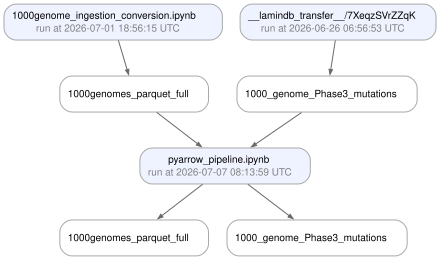

In [9]:
# --- governance demos ---
# 1. Schema validation rejects bad data at SAVE time, not query time.
#    The registered schema is flexible — build a closed version for the demo.
import pandas as pd
members = list(ln.Schema.get(name=SCHEMA_NAME).members.all())
strict = ln.Schema(features=members, minimal_set=True, maximal_set=True).save()

bad = pd.DataFrame({"wrong_column": [1, 2, 3]})
try:
    ln.Artifact.from_dataframe(
        bad, key="lakehouse-benchmarks/should_fail.parquet",
        description="invalid artifact (governance demo)", schema=strict,
    ).save()
    print("governance: WARNING — invalid artifact was NOT rejected")
except Exception as e:
    print(f"governance: schema validation rejected bad data ({type(e).__name__})")

# 2. Lineage — trace where the new collection version came from.
new_collection.view_lineage()

In [10]:
b.record(query_source=QUERY_SOURCE)
ln.finish()

→ creating new artifact version for key 'benchmark_results/pyarrow.parquet' in storage 's3://lamin-eu-central-1/MBiQHz7l46Jk'
... uploading tdRhABkocQ6VVl820009.parquet: 100.0%
• replacing the existing cache path /home/sagemaker-user/.cache/lamindb/lamin-eu-central-1/MBiQHz7l46Jk/benchmark_results/pyarrow.parquet

recorded 7 steps -> benchmark_results/pyarrow.parquet
• please hit CTRL + s to save the notebook in your editor  ✓
! cells [(5, 7)] were not run consecutively
→ finished Run('EStVXE1vGaxgN393') after 47m at 2026-07-07 09:01:07 UTC
→ go to: https://lamin.ai/laminlabs/lakehouse-benchmarks/run/EStVXE1vGaxgN393
→ to update your notebook from the CLI, run: lamin save /home/sagemaker-user/lakehouse-benchmarks/pyarrow_pipeline.ipynb
